In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import math
import random
import seaborn as sns
import matplotlib.pyplot as plt
# Sirve para medir la velocidad de una función
import time
%load_ext line_profiler
import sys
sys.path.insert(1, '/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Codigos/Funciones_utiles_f')
import funciones_aux_bootstrap_f_r as fab
from scipy.stats import variation

In [2]:
# Importamos los datos para el análisis
df_act_yuc_i=pd.read_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases/Base elecciones analsis/base_elecciones_yuc_analsis.csv", index_col=0)
df_act_yuc_i

,ID ESTADO,NOMBRE ESTADO,DISTRITO,SECCION,CASILLA,ID CASILLA,ESTATUS ACTA,PAN,PRI,PRD,...,CANDIDATOS NO REGISTRADOS,VOTOS NULOS,LISTA NOMINAL,TOTAL,PARTICIPACIÓN,JOAQUIN_DIAZ_MENA,RENAN_BARRERA_CONCHA,VIDA_ARAVARI_GOMEZ_HERRERA,YAMIL_JASMIN_LOPEZ_MANRIQUE,VOTOS_NULOS_CAND_NO_REGIS
0,31,YUCATÁN,12,1,'0001B1,1,COMPUTADA,171.0,107.0,3.0,...,0.0,12.0,596.0,532.0,0.892617,209.0,290.0,18.0,3.0,12.0
1,31,YUCATÁN,12,1,'0001C1,2,COMPUTADA,177.0,104.0,0.0,...,0.0,11.0,596.0,547.0,0.917785,208.0,299.0,29.0,0.0,11.0
2,31,YUCATÁN,12,1,'0001C2,3,COMPUTADA,176.0,100.0,1.0,...,0.0,13.0,595.0,542.0,0.910924,228.0,289.0,11.0,1.0,13.0
3,31,YUCATÁN,12,2,'0002B1,4,COMPUTADA,46.0,33.0,2.0,...,0.0,3.0,174.0,162.0,0.931034,71.0,79.0,7.0,2.0,3.0
4,31,YUCATÁN,12,4,'0004B1,6,COMPUTADA,110.0,96.0,7.0,...,0.0,14.0,550.0,513.0,0.932727,275.0,207.0,10.0,7.0,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2836,31,YUCATÁN,3,1195,'1195V1,2967,COMPUTADA,2.0,0.0,0.0,...,0.0,0.0,0.0,2.0,0.000000,0.0,2.0,0.0,0.0,0.0
2837,31,YUCATÁN,5,1197,'1197V1,2969,COMPUTADA,2.0,1.0,0.0,...,0.0,0.0,0.0,5.0,0.000000,2.0,3.0,0.0,0.0,0.0
2838,31,YUCATÁN,8,1199,'1199V1,2971,COMPUTADA,2.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.000000,1.0,2.0,0.0,0.0,0.0
2839,31,YUCATÁN,9,1200,'1200V1,2972,COMPUTADA,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.000000,1.0,0.0,0.0,0.0,0.0


In [3]:
# Datos reales de la proporción
prop_reales=df_act_yuc_i[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum()/df_act_yuc_i[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum().sum()
prop_reales

JOAQUIN_DIAZ_MENA              0.515125
RENAN_BARRERA_CONCHA           0.421366
VIDA_ARAVARI_GOMEZ_HERRERA     0.036792
YAMIL_JASMIN_LOPEZ_MANRIQUE    0.005249
VOTOS_NULOS_CAND_NO_REGIS      0.021467
dtype: float64

## Sin estratificar

In [4]:
def votos_var_sim_met_2(df, num_boot: int=1000, n_sample=None, n_vot_sub=2000, semilla=1):

    est_punt_list=[]

    inter_list=[]

    # Número total de votos
    n_votos=int(df[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum().sum())

    # Semilla para las muestras de la Dirichlet
    rng = np.random.default_rng()

    # Semilla para los conteos de votos (eventualmente se tiene que mover adentro del for para que sea reproducible el código)
    rng_2 = np.random.default_rng()

    # Varianza de los muestras de votos
    var_votos=[]

    for i in range(num_boot):

        # Semilla para que el código sea reproducible
        # Cambiamos el valor en el for
        rng = np.random.default_rng((num_boot*semilla)+i+1)

        df_stra_sam = df.sample(n=n_sample, random_state= rng)

        df_stra_sam=np.array(df_stra_sam[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]])

        # Semilla para las muestras de la Dirichlet
        rng = np.random.default_rng((i+1)+(num_boot*(semilla+1)))
 
        # Submuestra de votos (en este caso son 2000)
        # Corrección del código inicial lo correcto es utilizar la distribución hipergeométrica multivariada.
        # Puesto que, se esta haciendo muestreo sin reemplazo y si utilizas la multinomial es muestreo con reemplazo.
        # La diferencia es mínima pero la hipergeométrica multivariada es la correcta.
        # Sacamos 1000 muestras distintas
        votos_subm=rng.multivariate_hypergeometric(colors=df_stra_sam.sum(0).astype(int), nsample=n_vot_sub, size=1000)

        # Los pesos de la distribución Dirichlet para las 1000 muestras distintas
        pesos_bootstrap=fab.dirichlet_sample(votos_subm, semilla=(i+1)+(num_boot*(semilla+2)))

        # Semilla para las muestras de la Dirichlet
        rng = np.random.default_rng((i+1)+(num_boot*(semilla+3)))

        # Simulamos las 1000 poblaciones de votos
        votos_sim=rng.multinomial(n=n_votos,  pvals=pesos_bootstrap)

        

        # Obtenemos las proporciones de los votos
        array_res=(votos_sim)/n_votos

        var_votos.append((votos_subm/n_vot_sub).var(0))

        # Los valores de los intervalos de probabilidad lower y upper
        inter_prob=np.concatenate((np.apply_along_axis(fab.inter_prob_l, axis=0, arr=array_res),np.apply_along_axis(fab.inter_prob_u, axis=0, arr=array_res)))
        
        # Estimaciones puntuales
        est_puntual=array_res.mean(0)

        # Guardamos las estimaciones puntuales
        est_punt_list.append(est_puntual)

        # Guardamos los intervalos
        inter_list.append(inter_prob)
        


    return np.array(var_votos)


In [5]:
var_votos_f=votos_var_sim_met_2(df_act_yuc_i, num_boot=1000, n_sample=350, n_vot_sub=500, semilla=11)

In [6]:
var_df_s=pd.DataFrame(var_votos_f.mean(0)).T
var_df_s.columns=["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]
var_df_s

,JOAQUIN_DIAZ_MENA,RENAN_BARRERA_CONCHA,VIDA_ARAVARI_GOMEZ_HERRERA,YAMIL_JASMIN_LOPEZ_MANRIQUE,VOTOS_NULOS_CAND_NO_REGIS
0,0.000497,0.000484,0.00007,0.00001,0.000042


In [7]:
# Probamos distintos valores de tamaño de la muestra de las casillas y la submuestra de votos
muestra_casillas = [100, 150, 200, 250, 300, 350, 400]
#submuestra_votos = [500, 1000, 1500, 2000, 3000, 4000]

# Edición especial con otras submuestras de votos
submuestra_votos = [500, 1000, 2000, 5000, 10000, 20000]

# Contador para el for
k=0

# Creamos el dataframe donde guardaremos los resultados
var_df_s=pd.DataFrame()

# Hacemos los for sobre el tamaño de las muestras y submuestras
for mc in muestra_casillas:
    for smv in submuestra_votos:
        # Para medir cuanto tiempo se tarda en correr
        loop_time = time.time()
        # Varianzas por votos (estratificado)
        var_votos_f=votos_var_sim_met_2(df_act_yuc_i, num_boot=1000, n_sample=mc, n_vot_sub=smv, semilla=k+1)

        # Los valores de las muestra y submuestras
        var_df_s.loc[k,["Tamaño_muestra_casillas","Tamaño_submuestra_votos"]]=[mc,smv]

        # Guardamos las varianzas promedio
        var_df_s.loc[k,["Var_JOAQUIN_DIAZ_MENA","Var_RENAN_BARRERA_CONCHA","Var_VIDA_ARAVARI_GOMEZ_HERRERA","Var_YAMIL_JASMIN_LOPEZ_MANRIQUE","Var_VOTOS_NULOS_CAND_NO_REGIS"]]=var_votos_f.mean(0)


        k=k+1
        
        print("Muestra casillas:", mc, "Submuestra votos:", smv)
        print('Tiempo que tarda correr una iteración del for {}'.format((time.time() - loop_time)))  

# Lo guardamos en otra base copia por si sin querer pongo a correr el código
var_df_s

Muestra casillas: 100 Submuestra votos: 500
Tiempo que tarda correr una iteración del for 1.8306069374084473
Muestra casillas: 100 Submuestra votos: 1000
Tiempo que tarda correr una iteración del for 1.7335610389709473
Muestra casillas: 100 Submuestra votos: 2000
Tiempo que tarda correr una iteración del for 1.7100872993469238
Muestra casillas: 100 Submuestra votos: 5000
Tiempo que tarda correr una iteración del for 1.852752923965454
Muestra casillas: 100 Submuestra votos: 10000
Tiempo que tarda correr una iteración del for 1.863699197769165
Muestra casillas: 100 Submuestra votos: 20000
Tiempo que tarda correr una iteración del for 1.8211669921875
Muestra casillas: 150 Submuestra votos: 500
Tiempo que tarda correr una iteración del for 1.8136332035064697
Muestra casillas: 150 Submuestra votos: 1000
Tiempo que tarda correr una iteración del for 1.9478051662445068
Muestra casillas: 150 Submuestra votos: 2000
Tiempo que tarda correr una iteración del for 1.7684118747711182
Muestra casilla

,Tamaño_muestra_casillas,Tamaño_submuestra_votos,Var_JOAQUIN_DIAZ_MENA,Var_RENAN_BARRERA_CONCHA,Var_VIDA_ARAVARI_GOMEZ_HERRERA,Var_YAMIL_JASMIN_LOPEZ_MANRIQUE,Var_VOTOS_NULOS_CAND_NO_REGIS
0,100,500,0.000492,0.000481,7.021969e-05,1.040056e-05,4.153226e-05
1,100,1000,0.000244,0.000239,3.452272e-05,5.061032e-06,2.046264e-05
2,100,2000,0.000119,0.000116,1.691221e-05,2.474446e-06,9.999257e-06
3,100,5000,0.000044,0.000043,6.300612e-06,9.129480e-07,3.702032e-06
4,100,10000,0.000019,0.000019,2.707412e-06,3.923045e-07,1.611313e-06
5,100,20000,0.000007,0.000006,9.487340e-07,1.365974e-07,5.604272e-07
6,150,500,0.000495,0.000483,7.001204e-05,1.040544e-05,4.144099e-05
7,150,1000,0.000246,0.000240,3.489078e-05,5.071406e-06,2.062200e-05
8,150,2000,0.000121,0.000118,1.719946e-05,2.522838e-06,1.021899e-05
9,150,5000,0.000046,0.000045,6.485142e-06,9.701024e-07,3.884082e-06


In [246]:
#var_df_s.to_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Analisis ad hoc/Var_bootstrap_votos_met_2_sim.csv")

## Gráficas

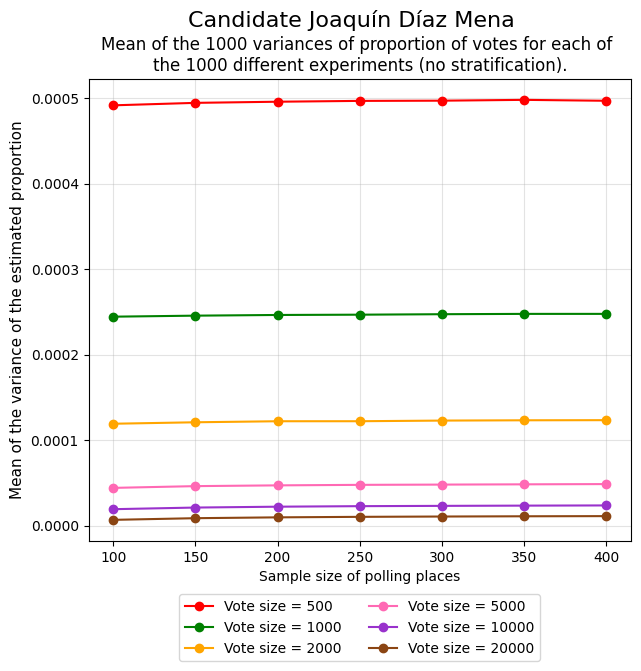

In [ ]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)

# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
#plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(var_df_s["Tamaño_submuestra_votos"].unique()):     
        plt.plot(var_df_s[(var_df_s["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 var_df_s[(var_df_s["Tamaño_submuestra_votos"] == j)]["Var_JOAQUIN_DIAZ_MENA"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')

plt.suptitle('Candidate Joaquín Díaz Mena', fontsize=16, y=0.995)

plt.title("Mean of the 1000 variances of proportion of votes for each of \nthe 1000 different experiments (no stratification).");
plt.ylabel(ylabel='Mean of the variance of the estimated proportion', fontsize=11);
plt.xlabel('Sample size of polling places')

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);

plt.savefig(r"/Users/damian/Documents/Tesis maestria/Imagenes/Casillas_vs_casillas_sub_votos_m_2/No estratificado/Analisis varianza/Joaquin_Diaz_Mena_casillas_sub_votos_m_2_no_est_anal_var.png", bbox_inches='tight',dpi=300);

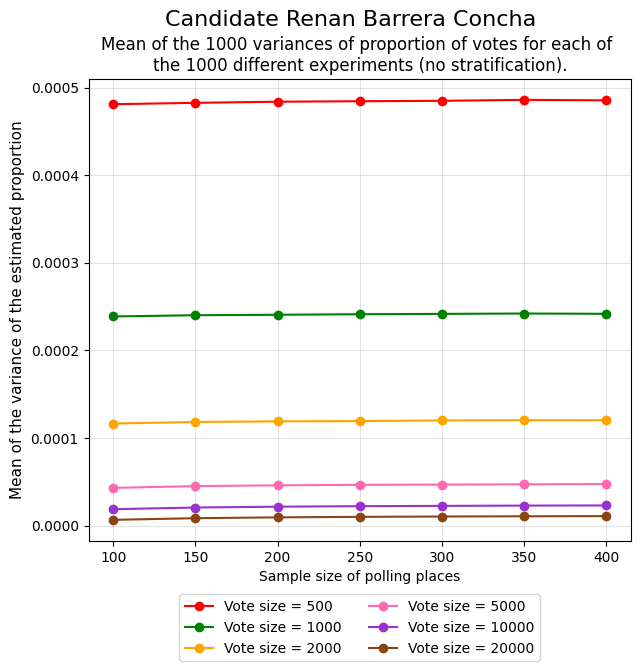

In [16]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)

# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
#plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(var_df_s["Tamaño_submuestra_votos"].unique()):     
        plt.plot(var_df_s[(var_df_s["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 var_df_s[(var_df_s["Tamaño_submuestra_votos"] == j)]["Var_RENAN_BARRERA_CONCHA"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')

plt.suptitle('Candidate Renan Barrera Concha', fontsize=16, y=0.995)

plt.title("Mean of the 1000 variances of proportion of votes for each of \nthe 1000 different experiments (no stratification).");
plt.ylabel(ylabel='Mean of the variance of the estimated proportion', fontsize=11);
plt.xlabel('Sample size of polling places')

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);
plt.savefig(r"/Users/damian/Documents/Tesis maestria/Imagenes/Casillas_vs_casillas_sub_votos_m_2/No estratificado/Analisis varianza/Renan_Barrera_Concha_casillas_sub_votos_m_2_no_est_anal_var.png", bbox_inches='tight',dpi=300);

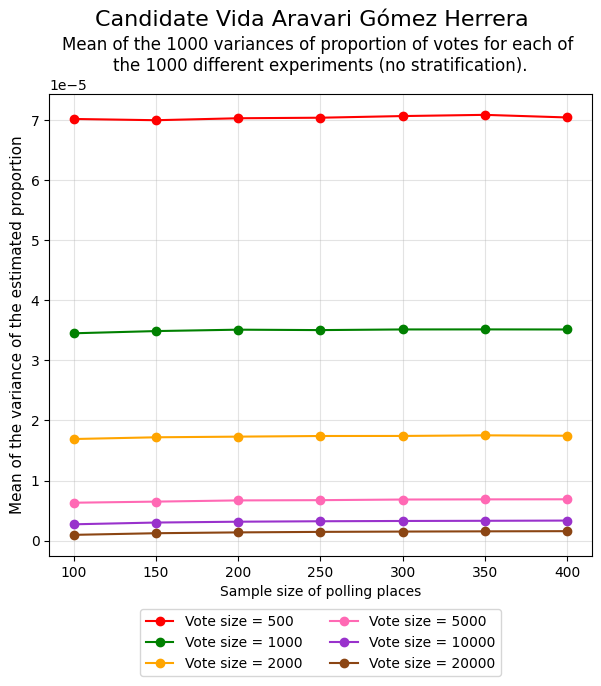

In [19]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)

# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
#plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(var_df_s["Tamaño_submuestra_votos"].unique()):     
        plt.plot(var_df_s[(var_df_s["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 var_df_s[(var_df_s["Tamaño_submuestra_votos"] == j)]["Var_VIDA_ARAVARI_GOMEZ_HERRERA"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')

plt.suptitle('Candidate Vida Aravari Gómez Herrera', fontsize=16, y=1.02)

plt.title("Mean of the 1000 variances of proportion of votes for each of \nthe 1000 different experiments (no stratification).");
plt.ylabel(ylabel='Mean of the variance of the estimated proportion', fontsize=11);
plt.xlabel('Sample size of polling places')

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);
plt.savefig(r"/Users/damian/Documents/Tesis maestria/Imagenes/Casillas_vs_casillas_sub_votos_m_2/No estratificado/Analisis varianza/Vida_Aravari_Gomez_Herrera_casillas_sub_votos_m_2_no_est_anal_var.png", bbox_inches='tight',dpi=300);

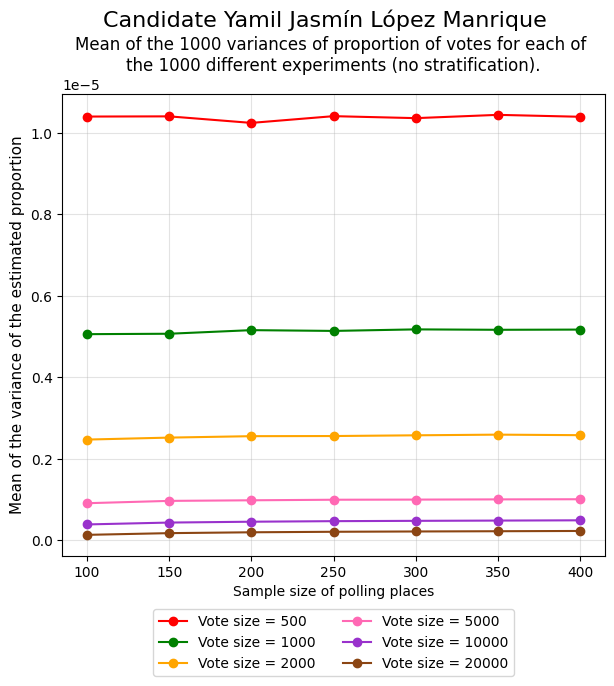

In [20]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)

# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
#plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(var_df_s["Tamaño_submuestra_votos"].unique()):     
        plt.plot(var_df_s[(var_df_s["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 var_df_s[(var_df_s["Tamaño_submuestra_votos"] == j)]["Var_YAMIL_JASMIN_LOPEZ_MANRIQUE"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')

plt.suptitle('Candidate Yamil Jasmín López Manrique', fontsize=16, y=1.02)

plt.title("Mean of the 1000 variances of proportion of votes for each of \nthe 1000 different experiments (no stratification).");
plt.ylabel(ylabel='Mean of the variance of the estimated proportion', fontsize=11);
plt.xlabel('Sample size of polling places')

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);
plt.savefig(r"/Users/damian/Documents/Tesis maestria/Imagenes/Casillas_vs_casillas_sub_votos_m_2/No estratificado/Analisis varianza/Jasmin_Lopez_Manrique_casillas_sub_votos_m_2_no_est_anal_var.png", bbox_inches='tight',dpi=300);

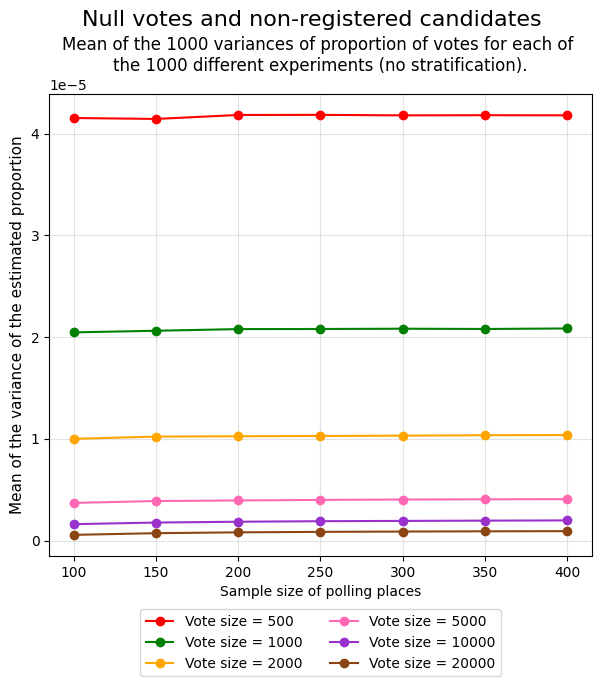

In [21]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)

# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
#plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(var_df_s["Tamaño_submuestra_votos"].unique()):     
        plt.plot(var_df_s[(var_df_s["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 var_df_s[(var_df_s["Tamaño_submuestra_votos"] == j)]["Var_VOTOS_NULOS_CAND_NO_REGIS"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')

plt.suptitle('Null votes and non-registered candidates', fontsize=16, y=1.02)

plt.title("Mean of the 1000 variances of proportion of votes for each of \nthe 1000 different experiments (no stratification).");
plt.ylabel(ylabel='Mean of the variance of the estimated proportion', fontsize=11);
plt.xlabel('Sample size of polling places')

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);
plt.savefig(r"/Users/damian/Documents/Tesis maestria/Imagenes/Casillas_vs_casillas_sub_votos_m_2/No estratificado/Analisis varianza/Votos_nulos_no_reg_casillas_sub_votos_m_2_no_est_anal_var.png", bbox_inches='tight',dpi=300);

## Estratificado (por distrito)

In [22]:
# Versión función
def votos_var_sim_met_est_2(df_act_yuc_i, num_boot: int=1000, n_sample=None, n_vot_sub=2000, semilla=1):

    # Listas auxiliares para guardar los datos
    est_punt_list=[]

    inter_list=[]

    # Cuantas votos hay por distrito
    array_frec_est=np.array(df_act_yuc_i.groupby('DISTRITO').agg({'TOTAL':'sum'}).reset_index(drop=True).astype(int)["TOTAL"])

    # Número de poblaciones
    n_boot=1000

    # Semilla para las muestras de la Dirichlet
    rng = np.random.default_rng()

    # Semilla para las muestras de la Dirichlet
    rng_2 = np.random.default_rng()

    # Los valores distintos de los distritos
    val_dist=df_act_yuc_i["DISTRITO"].sort_values().unique()

    # Varianza de los muestras de votos
    var_votos=[]

    for i in range(num_boot):

        # Hacemos el muestreo de tamaño n_sample de las casilas estratificado por distrito
        df_stra_sam=fab.muestreo_estratificado_mej(df_act_yuc_i, ["DISTRITO"], sample_size=n_sample, semilla=i+1+(num_boot*semilla))

        # Guardamos en un numpy array el dataframe de la muestra
        array_muest=np.array(df_stra_sam[["DISTRITO","JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]])

        # Corrección porque el muestreo estratificado es de votos
        # Porcentaje del total de votos por estrato (distrito)
        array_pesos_normalizados_dist=np.array(df_stra_sam.groupby('DISTRITO').agg({'TOTAL':'sum'}).div(df_stra_sam["TOTAL"].sum()).sort_index()["TOTAL"])

        # Obtenemos los totales de las proporciones para cada estrato (distrito)
        #totales_prop_est=fab.obtener_totales(array_pesos_normalizados_dist, n_vot_sub)
        totales_prop_est=fab.obtener_totales(array_pesos_normalizados_dist, n_vot_sub).astype(int)

        # Los porcentajes de cada distrito en la submuestra de votos
        array_pesos_normalizados_sub=totales_prop_est/totales_prop_est.sum()

        # Submuestra de votos por distrito (estrato)
        # Corrección del código inicial lo correcto es utilizar la distribución hipergeométrica multivariada.
        # Puesto que, se esta haciendo muestreo sin reemplazo y si utilizas la multinomial es muestreo con reemplazo.
        # La diferencia es mínima pero la hipergeométrica multivariada es la correcta.
        votos_subm_d=[np.random.default_rng(index+((i+1)+(num_boot*(semilla+1)))).multivariate_hypergeometric(colors=array_muest[array_muest[:,0]==val][:,1:].sum(0).astype(int), nsample=totales_prop_est[val-1], size=1000) for index, val in enumerate(val_dist)]

        # Vector de pesos de la distribución Dirichlet

        var_votos.append((np.array(votos_subm_d).sum(0)/n_vot_sub).var(0))


        # Obtenemos los vectores Dirichlet para cada uno de los estratos
        #vectores_dir=[fab.dirichlet_sample(xi, semilla=(i+1)+(num_boot*(semilla+2))) for xi in votos_subm_d]

        # Donde se van a guardar los resultados
        array_res=np.zeros((n_boot,5))

        # # Completamos la muestra mediante el bootstrap bayesiano en cada estrato
        # for k in val_dist:

        #     # Semilla para las muestras de la Multinomial
        #     rng_2 = np.random.default_rng((num_boot*(semilla+3))+(i+1+k))
            
        #     # Total de votos de la muestra simulada (utilizando una multinomial)
        #     votos_sim=rng_2.multinomial(n=array_frec_est[k-1],  pvals=vectores_dir[k-1])

        #     # Guardamos todo en un array con las estimaciones (se van sumando las iteraciones para alcanzar el 100%)
        #     array_res=array_res+(votos_sim/votos_sim.sum(1)[0]*array_pesos_normalizados_sub[k-1])

    

    
    return np.array(var_votos)


In [23]:
var_votos_f_est=votos_var_sim_met_est_2(df_act_yuc_i, num_boot=1000, n_sample=350, n_vot_sub=15000, semilla=11)

## Gráficas

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

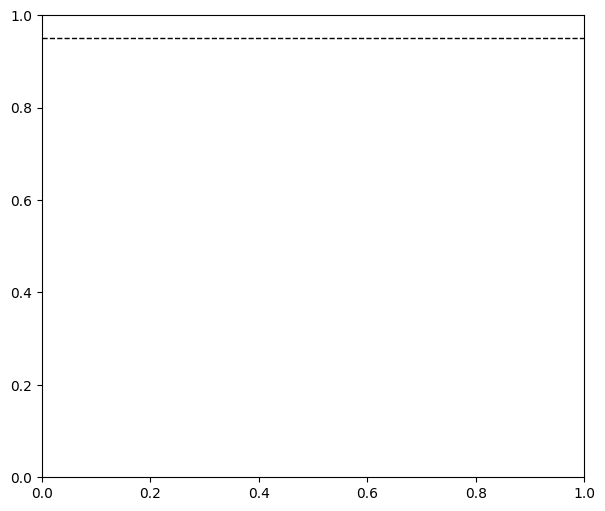

In [24]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)

# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(var_votos_f_est["Tamaño_submuestra_votos"].unique()):     
        plt.plot(var_votos_f_est[(var_votos_f_est["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 var_votos_f_est[(var_votos_f_est["Tamaño_submuestra_votos"] == j)]["Cob_JOAQUIN_DIAZ_MENA"],
                 color=colors_plot[ind_j], label=f'Sample size of votes = {j}', linestyle='solid',  marker='o')

plt.suptitle('Coverage of Joaquín Díaz Mena', fontsize=16, y=1.03)
plt.title('Comparison of bootstrap estimates for sampling \npolling places only versus sampling polling places \nthen votes (method 2 and no stratification)');
plt.ylabel(ylabel='Coverage');
plt.xlabel('Sample size of polling places')

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);

In [25]:
# Probamos distintos valores de tamaño de la muestra de las casillas y la submuestra de votos
muestra_casillas = [100, 150, 200, 250, 300, 350, 400]
#submuestra_votos = [500, 1000, 1500, 2000, 3000, 4000]

# Edición especial con otras submuestras de votos
submuestra_votos = [500, 1000, 2000, 5000, 10000, 20000]

# Contador para el for
k=0

# Creamos el dataframe donde guardaremos los resultados
var_df_s_est=pd.DataFrame()

# Hacemos los for sobre el tamaño de las muestras y submuestras
for mc in muestra_casillas:
    for smv in submuestra_votos:
        # Para medir cuanto tiempo se tarda en correr
        loop_time = time.time()
        # Varianzas por votos (estratificado)
        var_votos_f_est=votos_var_sim_met_est_2(df_act_yuc_i, num_boot=1000, n_sample=mc, n_vot_sub=smv, semilla=k+1)

        # Los valores de las muestra y submuestras
        var_df_s_est.loc[k,["Tamaño_muestra_casillas","Tamaño_submuestra_votos"]]=[mc,smv]

        # Guardamos las varianzas promedio
        var_df_s_est.loc[k,["Var_JOAQUIN_DIAZ_MENA","Var_RENAN_BARRERA_CONCHA","Var_VIDA_ARAVARI_GOMEZ_HERRERA","Var_YAMIL_JASMIN_LOPEZ_MANRIQUE","Var_VOTOS_NULOS_CAND_NO_REGIS"]]=var_votos_f_est.mean(0)

        k=k+1
        
        print("Muestra casillas:", mc, "Submuestra votos:", smv)
        print('Tiempo que tarda correr una iteración del for {}'.format((time.time() - loop_time)))  
        
# Lo guardamos en otra base copia por si sin querer pongo a correr el código
var_df_s_est

Muestra casillas: 100 Submuestra votos: 500
Tiempo que tarda correr una iteración del for 8.187485933303833
Muestra casillas: 100 Submuestra votos: 1000
Tiempo que tarda correr una iteración del for 8.576061964035034
Muestra casillas: 100 Submuestra votos: 2000
Tiempo que tarda correr una iteración del for 9.092223882675171
Muestra casillas: 100 Submuestra votos: 5000
Tiempo que tarda correr una iteración del for 10.789766073226929
Muestra casillas: 100 Submuestra votos: 10000
Tiempo que tarda correr una iteración del for 12.353088855743408
Muestra casillas: 100 Submuestra votos: 20000
Tiempo que tarda correr una iteración del for 12.736598014831543
Muestra casillas: 150 Submuestra votos: 500
Tiempo que tarda correr una iteración del for 8.65559196472168
Muestra casillas: 150 Submuestra votos: 1000
Tiempo que tarda correr una iteración del for 9.429841756820679
Muestra casillas: 150 Submuestra votos: 2000
Tiempo que tarda correr una iteración del for 9.609026193618774
Muestra casillas:

,Tamaño_muestra_casillas,Tamaño_submuestra_votos,Var_JOAQUIN_DIAZ_MENA,Var_RENAN_BARRERA_CONCHA,Var_VIDA_ARAVARI_GOMEZ_HERRERA,Var_YAMIL_JASMIN_LOPEZ_MANRIQUE,Var_VOTOS_NULOS_CAND_NO_REGIS
0,100,500,0.000473,0.000461,6.793523e-05,1.019334e-05,4.121074e-05
1,100,1000,0.000234,0.000228,3.347525e-05,5.111051e-06,2.038648e-05
2,100,2000,0.000114,0.000111,1.638665e-05,2.469617e-06,9.951288e-06
3,100,5000,0.000042,0.000041,6.065989e-06,9.169734e-07,3.676951e-06
4,100,10000,0.000018,0.000018,2.628962e-06,3.965158e-07,1.605089e-06
5,100,20000,0.000006,0.000006,9.066534e-07,1.396477e-07,5.558157e-07
6,150,500,0.000476,0.000463,6.916550e-05,1.028722e-05,4.174912e-05
7,150,1000,0.000237,0.000230,3.437879e-05,5.055530e-06,2.069292e-05
8,150,2000,0.000116,0.000113,1.691859e-05,2.503319e-06,1.019884e-05
9,150,5000,0.000044,0.000043,6.458615e-06,9.469511e-07,3.867333e-06


In [245]:
#var_df_s_est.to_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Analisis ad hoc/Var_bootstrap_votos_met_2_est.csv")

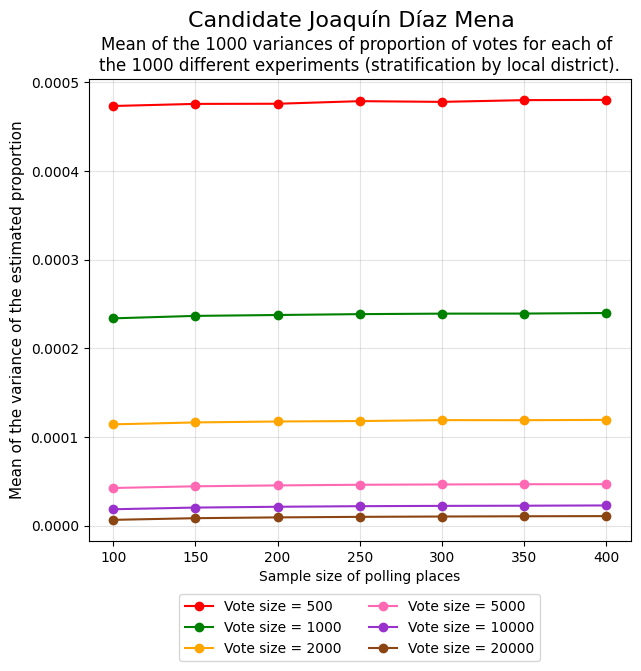

In [26]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)

# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
#plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(var_df_s_est["Tamaño_submuestra_votos"].unique()):     
        plt.plot(var_df_s_est[(var_df_s_est["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 var_df_s_est[(var_df_s_est["Tamaño_submuestra_votos"] == j)]["Var_JOAQUIN_DIAZ_MENA"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')

plt.suptitle('Candidate Joaquín Díaz Mena', fontsize=16, y=0.995)

plt.title("Mean of the 1000 variances of proportion of votes for each of \nthe 1000 different experiments (stratification by local district).");
plt.ylabel(ylabel='Mean of the variance of the estimated proportion', fontsize=11);
plt.xlabel('Sample size of polling places')

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);
plt.savefig(r"/Users/damian/Documents/Tesis maestria/Imagenes/Casillas_vs_casillas_sub_votos_m_2/Estratificado/Analisis varianza/Joaquin_Diaz_Mena_casillas_sub_votos_m_2_est_anal_var.png", bbox_inches='tight',dpi=300);

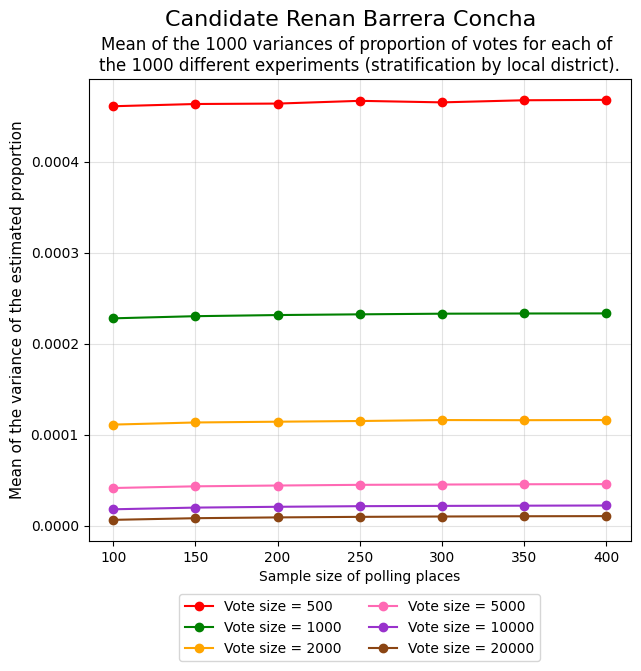

In [27]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)

# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
#plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(var_df_s_est["Tamaño_submuestra_votos"].unique()):     
        plt.plot(var_df_s_est[(var_df_s_est["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 var_df_s_est[(var_df_s_est["Tamaño_submuestra_votos"] == j)]["Var_RENAN_BARRERA_CONCHA"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')

plt.suptitle('Candidate Renan Barrera Concha', fontsize=16, y=0.995)

plt.title("Mean of the 1000 variances of proportion of votes for each of \nthe 1000 different experiments (stratification by local district).");
plt.ylabel(ylabel='Mean of the variance of the estimated proportion', fontsize=11);
plt.xlabel('Sample size of polling places')

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);
plt.savefig(r"/Users/damian/Documents/Tesis maestria/Imagenes/Casillas_vs_casillas_sub_votos_m_2/Estratificado/Analisis varianza/Renan_Barrera_Concha_casillas_sub_votos_m_2_est_anal_var.png", bbox_inches='tight',dpi=300);

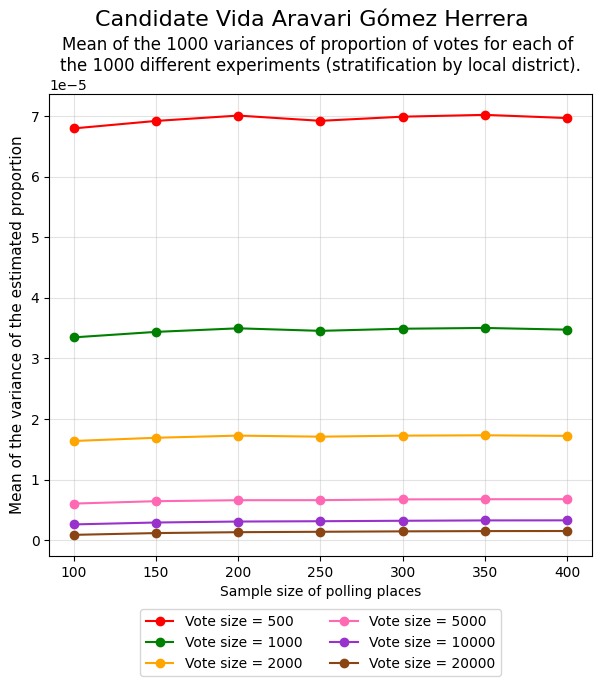

In [28]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)

# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
#plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(var_df_s_est["Tamaño_submuestra_votos"].unique()):     
        plt.plot(var_df_s_est[(var_df_s_est["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 var_df_s_est[(var_df_s_est["Tamaño_submuestra_votos"] == j)]["Var_VIDA_ARAVARI_GOMEZ_HERRERA"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')

plt.suptitle('Candidate Vida Aravari Gómez Herrera', fontsize=16, y=1.02)

plt.title("Mean of the 1000 variances of proportion of votes for each of \nthe 1000 different experiments (stratification by local district).");
plt.ylabel(ylabel='Mean of the variance of the estimated proportion', fontsize=11);
plt.xlabel('Sample size of polling places')

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);
plt.savefig(r"/Users/damian/Documents/Tesis maestria/Imagenes/Casillas_vs_casillas_sub_votos_m_2/Estratificado/Analisis varianza/Vida_Aravari_Gomez_Herrera_casillas_sub_votos_m_2_est_anal_var.png", bbox_inches='tight',dpi=300);

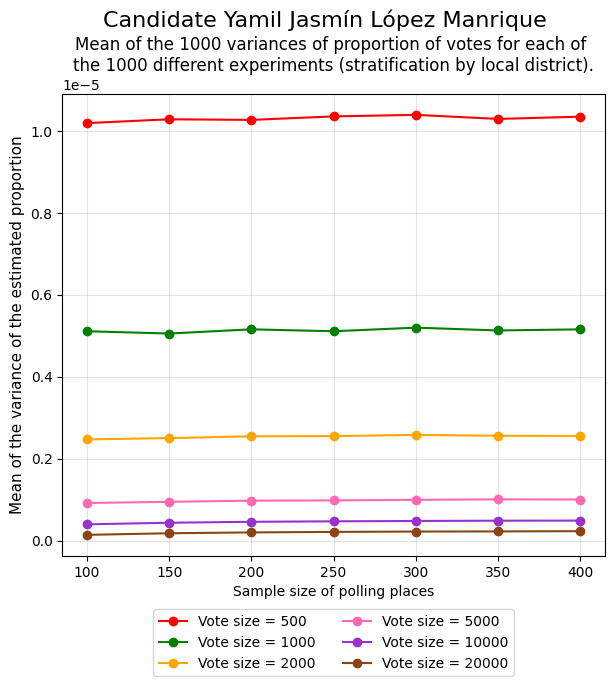

In [29]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)

# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
#plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(var_df_s_est["Tamaño_submuestra_votos"].unique()):     
        plt.plot(var_df_s_est[(var_df_s_est["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 var_df_s_est[(var_df_s_est["Tamaño_submuestra_votos"] == j)]["Var_YAMIL_JASMIN_LOPEZ_MANRIQUE"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')

plt.suptitle('Candidate Yamil Jasmín López Manrique', fontsize=16, y=1.02)

plt.title("Mean of the 1000 variances of proportion of votes for each of \nthe 1000 different experiments (stratification by local district).");
plt.ylabel(ylabel='Mean of the variance of the estimated proportion', fontsize=11);
plt.xlabel('Sample size of polling places')

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);
plt.savefig(r"/Users/damian/Documents/Tesis maestria/Imagenes/Casillas_vs_casillas_sub_votos_m_2/Estratificado/Analisis varianza/Jasmin_Lopez_Manrique_casillas_sub_votos_m_2_est_anal_var.png", bbox_inches='tight',dpi=300);

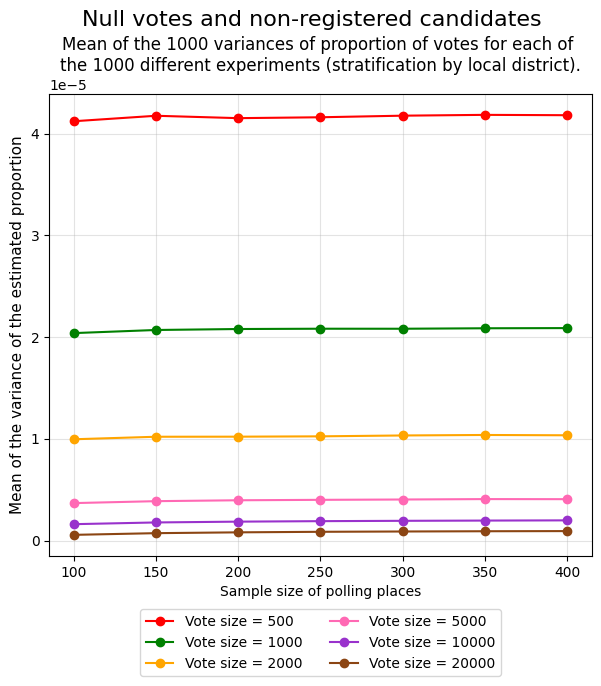

In [30]:
# Tamaño de la gráfica
fig = plt.figure(figsize=(7, 6), dpi=100)

# Para guardar la imagen
#fig = plt.figure(figsize=(7, 6), dpi=300)

# Colores para la gráfica
colors_plot = ["red", "green", "orange", "hotpink", "darkorchid", "saddlebrown", "mediumturquoise"]
#plt.axhline(y=0.95, linewidth=1, color='black', ls='--');
l=0
# Para graficar todos las rectas de los votos
for ind_j, j in enumerate(var_df_s_est["Tamaño_submuestra_votos"].unique()):     
        plt.plot(var_df_s_est[(var_df_s_est["Tamaño_submuestra_votos"] == j)]["Tamaño_muestra_casillas"], 
                 var_df_s_est[(var_df_s_est["Tamaño_submuestra_votos"] == j)]["Var_VOTOS_NULOS_CAND_NO_REGIS"],
                 color=colors_plot[ind_j], label=f'Vote size = {j}', linestyle='solid',  marker='o')

plt.suptitle('Null votes and non-registered candidates', fontsize=16, y=1.02)

plt.title("Mean of the 1000 variances of proportion of votes for each of \nthe 1000 different experiments (stratification by local district).");
plt.ylabel(ylabel='Mean of the variance of the estimated proportion', fontsize=11);
plt.xlabel('Sample size of polling places')

# Juntamos los títulos y las leyendas con un nombre
plt.legend(bbox_to_anchor=(0.5, -0.1), loc="upper center", shadow=False, ncol=2);

plt.grid(alpha=0.35);
plt.savefig(r"/Users/damian/Documents/Tesis maestria/Imagenes/Casillas_vs_casillas_sub_votos_m_2/Estratificado/Analisis varianza/Votos_nulos_no_reg_casillas_sub_votos_m_2_est_anal_var.png", bbox_inches='tight',dpi=300);